# Pre-training on GENERATED data

# 1. Load dataloaders 

In [1]:
from data.dataloader import create_dataloaders

train_dataloader, val_dataloader = create_dataloaders(
    csv_path= "../project_datasets/metadata/generated_metadata.csv",
    batch_size= 128,
)

✓ Converted boolean column 'appearance_in_kinship' to numeric (True=1, False=0, -1=-1)
✓ Converted boolean column 'appearance_in_first_grade_kinship' to numeric (True=1, False=0, -1=-1)
✓ Converted 'Gender' column to numeric (Male=1, Female=0)
Train dataset size:      80000
Validation dataset size: 20000
-----------------------------------------
Train dataloader steps:  625
Val dataloader steps:    157


# 2. Load model
- EfficientNet-B0: 5M

In [2]:
from model_efficientnetB0 import EfficientNet1D

model = EfficientNet1D()

model_name = "EfficientNetB0"

# 3. Train model

In [ ]:
from training.trainer import train


train(
    model= model,
    train_dataloader= train_dataloader,
    val_dataloader= val_dataloader,
    
    model_name= model_name,
    run_name= model_name,
    
    epochs= 20,
    max_lr = 1e-3,
)

In [4]:
# !tensorboard --logdir=runs

# 4. Plot confusion matrix (of the best model)

In [15]:
import torch
from model_efficientnetB0 import EfficientNet1D

model = EfficientNet1D()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
load_pretrained = "checkpoints/EfficientNetB0_BEST.pth"

# load checkpoint
checkpoint = torch.load(load_pretrained, map_location=device)
# load model
model.load_state_dict(checkpoint['model_state_dict'])

print(f"Loaded pretrained model:")
print(f"- val_loss={checkpoint['val_loss']:.4f}")
print(f"- val_acc={checkpoint['val_acc']:.4f}")
print(f"- val_recall={checkpoint['val_recall']:.4f}")
print(f"- val_precision={checkpoint['val_precision']:.4f}")
print(f"- val_f1={checkpoint['val_f1']:.4f}")

Loaded pretrained model:
- val_loss=0.0960
- val_acc=0.9831
- val_recall=0.9787
- val_precision=0.9878
- val_f1=0.9831


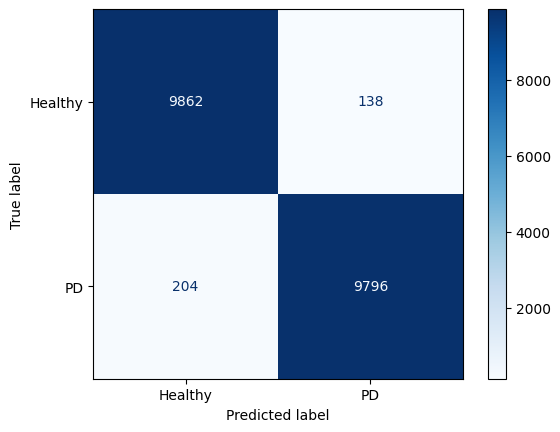

In [16]:
from training.confusion_mat import plot_confusion_matrix

plot_confusion_matrix(
    model=model,
    dataloader=val_dataloader,
    device=device,
    class_names=["Healthy", "PD"],
    threshold=0.45,
)